<a href="https://colab.research.google.com/github/Katab-sawan/Dissertation/blob/Random-Forest-Models/RandomForestTsla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/TSLA.csv')

df = df.dropna()
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800000,5.000000,3.508000,4.778000,4.778000,93831500
1,2010-06-30,5.158000,6.084000,4.660000,4.766000,4.766000,85935500
2,2010-07-01,5.000000,5.184000,4.054000,4.392000,4.392000,41094000
3,2010-07-02,4.600000,4.620000,3.742000,3.840000,3.840000,25699000
4,2010-07-06,4.000000,4.000000,3.166000,3.222000,3.222000,34334500
...,...,...,...,...,...,...,...
2951,2022-03-18,874.489990,907.849976,867.390015,905.390015,905.390015,33408500
2952,2022-03-21,914.979980,942.849976,907.090027,921.159973,921.159973,27327200
2953,2022-03-22,930.000000,997.859985,921.750000,993.979980,993.979980,35289500
2954,2022-03-23,979.940002,1040.699951,976.400024,999.109985,999.109985,40225400


(array([-500.,    0.,  500., 1000., 1500., 2000., 2500., 3000., 3500.]),
 [Text(-500.0, 0, '2020-04-01'),
  Text(0.0, 0, '2010-06-29'),
  Text(500.0, 0, '2012-06-21'),
  Text(1000.0, 0, '2014-06-19'),
  Text(1500.0, 0, '2016-06-14'),
  Text(2000.0, 0, '2018-06-08'),
  Text(2500.0, 0, '2020-06-04'),
  Text(3000.0, 0, ''),
  Text(3500.0, 0, '')])

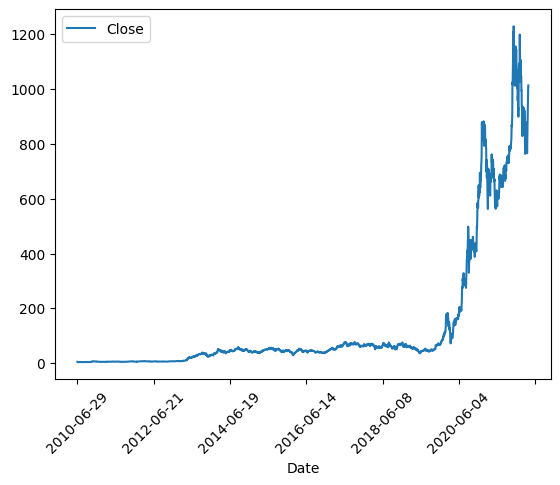

In [ ]:
df.plot (x='Date', y='Close')
plt.xticks(rotation = 45)

In [ ]:
model = RandomForestRegressor()

In [ ]:
X = df[['Open', 'High', 'Low', 'Volume']]
X = X[:int(len(df) - 1)]

y = df['Close']
y = y[:int(len(df) -1)]
model.fit(X,y)

RandomForestRegressor()

In [ ]:
predictions = model.predict(X)
print('The model Score is:', model.score(X,y))

The model Score is: 0.9999260853518505


In [ ]:
new_data = df[['Open', 'High', 'Low', 'Volume']].tail(1)
prediction = model.predict(new_data)
print('The model predicts the last price is:', prediction)
print('The actual value is:', df[['Close']].tail(1).values[0][0])

The model predicts the last price is: [1010.52962034]
The actual value is: 1013.919983


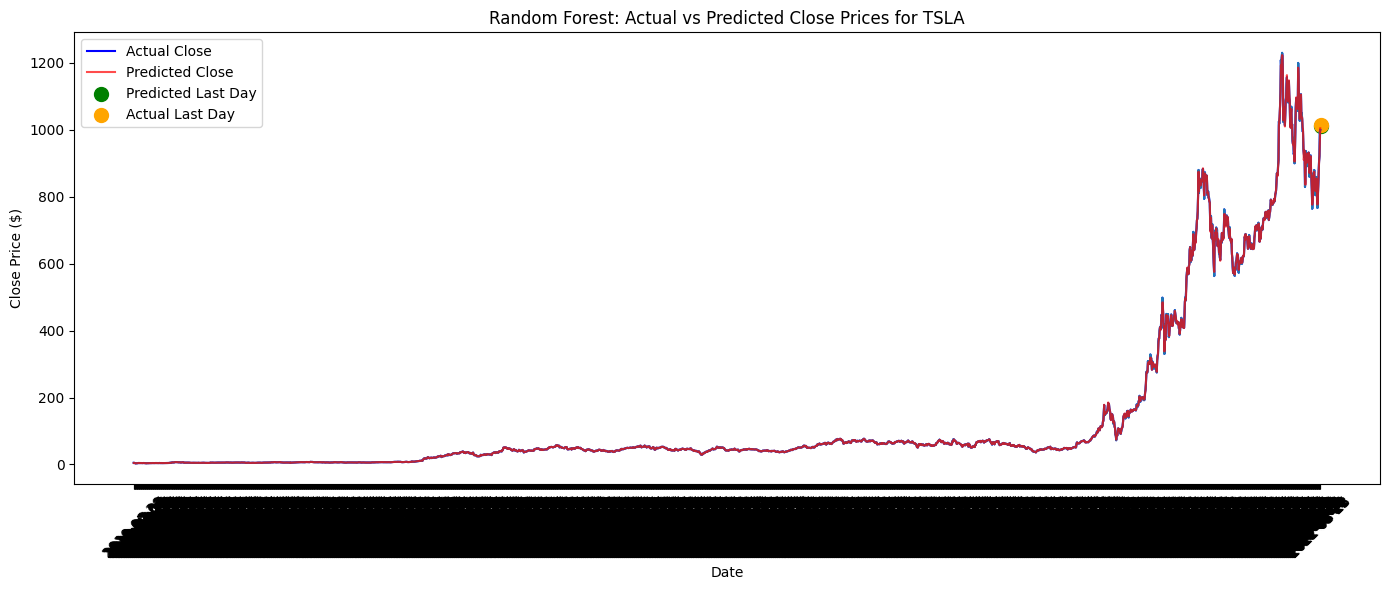

In [ ]:

plt.figure(figsize=(14,6))
plt.plot(df.index[:-1], y, label='Actual Close', color='blue')
plt.plot(df['Date'][:-1], y)
plt.plot(df.index[:-1], predictions, label='Predicted Close', color='red', alpha=0.7)
plt.scatter(df.index[-1], prediction[0], color='green', s=100, label='Predicted Last Day')
plt.scatter(df.index[-1], df['Close'].iloc[-1], color='orange', s=100, label='Actual Last Day')


plt.title('Random Forest: Actual vs Predicted Close Prices for TSLA')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(y, predictions)
mae = mean_absolute_error(y, predictions)
rmse = np.sqrt(mse)

print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')

Mean Squared Error (MSE): 4.6051
Mean Absolute Error (MAE): 0.7069
Root Mean Squared Error (RMSE): 2.1459
